In [1]:
import warnings
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

In [2]:
# Adapted from https://github.com/OpenFreeEnergy/cinnabar/blob/26eecb75bdbb5d7baf8798615feed16effe62abb/cinnabar/stats.py#L8
def bootstrap_statistic(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dy_true: Union[np.ndarray, None] = None,
    dy_pred: Union[np.ndarray, None] = None,
    ci: float = 0.95,
    statistic: str = "RMSE",
    nbootstrap: int = 10000,
    plot_type: str = "dG",
    include_true_uncertainty: bool = False,
    include_pred_uncertainty: bool = False,
) -> dict:
    """
    Compute mean and confidence intervals of specified statistic.

    Parameters
    ----------
    y_true : ndarray with shape (N,)
        True values
    y_pred : ndarray with shape (N,)
        Predicted values
    dy_true : ndarray with shape (N,) or None
        Errors of true values. If None, the values are assumed to have no errors
    dy_pred : ndarray with shape (N,) or None
        Errors of predicted values. If None, the values are assumed to have no errors
    ci : float, optional, default=0.95
        Interval for confidence interval (CI)
    statistic : str
        Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','KTAU','RAE']
    nbootstrap : int, optional, default=1000
        Number of bootstrap samples
    plot_type : str, optional, default='dG'
        'dG' or 'ddG'
    include_true_uncertainty : bool, default False
        whether to account for the uncertainty in y_true when bootstrapping
    include_pred_uncertainty : bool, default False
        whether to account for the uncertainty in y_pred when bootstrapping

    Returns
    -------
    rmse_stats : dict of float
        'mean' : mean RMSE
        'stderr' : standard error
        'low' : low end of CI
        'high' : high end of CI
    """

    def compute_statistic(
        y_true_sample: np.ndarray, y_pred_sample: np.ndarray, statistic: str
    ):
        """Compute requested statistic.

        Parameters
        ----------
        y_true : ndarray with shape (N,)
            True values
        y_pred : ndarray with shape (N,)
            Predicted values
        statistic : str
            Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','RAE','KTAU']

        """

        def calc_RAE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            MAE = sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
            mean = np.mean(y_true_sample)
            MAD = np.sum([np.abs(mean - i) for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            return MAE / MAD

        def calc_RRMSE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            rmse = np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
            mean_exp = np.mean(y_true_sample)
            mds = np.sum([(mean_exp - i) ** 2 for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            rrmse = np.sqrt(rmse**2 / mds)
            return rrmse

        if statistic == "RMSE":
            return np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
        elif statistic == "MUE":
            return sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
        elif statistic == "MSE":
            # mean signed error
            return np.mean(y_pred_sample - y_true_sample)
        elif statistic == "R2":
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(
                y_true_sample, y_pred_sample
            )
            return r_value**2
        elif statistic == "rho":
            return scipy.stats.pearsonr(y_true_sample, y_pred_sample)[0]
        elif statistic == "RAE":
            return calc_RAE(y_true_sample, y_pred_sample)
        elif statistic == "KTAU":
            return scipy.stats.kendalltau(y_true_sample, y_pred_sample)[0]
        else:
            raise Exception("unknown statistic '{}'".format(statistic))

    # not used?
    def unique_differences(x):
        """Compute all unique differences"""
        N = len(x)
        return np.array([(x[i] - x[j]) for i in range(N) for j in range(N) if (i != j)])

    if dy_true is None:
        dy_true = np.zeros_like(y_true)
    if dy_pred is None:
        dy_pred = np.zeros_like(y_pred)
    assert len(y_true) == len(y_pred)
    assert len(y_true) == len(dy_true)
    assert len(y_true) == len(dy_pred)
    sample_size = len(y_true)
    s_n = np.zeros(
        [nbootstrap], np.float64
    )  # s_n[n] is the statistic computed for bootstrap sample n
    for replicate in range(nbootstrap):
        y_true_sample = np.zeros_like(y_true)
        y_pred_sample = np.zeros_like(y_pred)
        for i, j in enumerate(
            np.random.choice(np.arange(sample_size), size=[sample_size], replace=True)
        ):
            stddev_true = np.fabs(dy_true[j]) if include_true_uncertainty else 0
            stddev_pred = np.fabs(dy_pred[j]) if include_pred_uncertainty else 0
            y_true_sample[i] = np.random.normal(
                loc=y_true[j], scale=stddev_true, size=1
            )
            y_pred_sample[i] = np.random.normal(
                loc=y_pred[j], scale=stddev_pred, size=1
            )
        s_n[replicate] = compute_statistic(y_true_sample, y_pred_sample, statistic)

    rmse_stats = dict()
    rmse_stats["mle"] = compute_statistic(y_true, y_pred, statistic)
    rmse_stats["stderr"] = np.std(s_n)
    rmse_stats["mean"] = np.mean(s_n)
    # TODO: Is there a canned method to do this?
    s_n = np.sort(s_n)
    low_frac = (1.0 - ci) / 2.0
    high_frac = 1.0 - low_frac
    rmse_stats["low"] = s_n[int(np.floor(nbootstrap * low_frac))]
    rmse_stats["high"] = s_n[int(np.ceil(nbootstrap * high_frac))]

    return rmse_stats

In [3]:
excel_file_path = "final_paper_LJ.xlsx"
pd.ExcelFile(excel_file_path).sheet_names

['EXP',
 'TRAIN-DS-RMIN-WAT',
 'TRAIN-DS-RMIN-CHX',
 'TRAIN-DS-MM-VACUUM-WAT',
 'TRAIN-DS-MM-VACUUM-CHX',
 'SAMPL5-WAT-EE',
 'SAMPL5-CHX-EE',
 'SAMPL5-WAT-ME',
 'SAMPL5-CHX-ME']

In [4]:
df_wat_emle = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-RMIN-WAT", header=1)
df_chx_emle = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-RMIN-CHX", header=1)
df_wat = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-MM-VACUUM-WAT", header=1)
df_chx = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-MM-VACUUM-CHX", header=1)

In [5]:
PATCHED_XDM_CHX_COLS = [
    "XDM-Rep1",
    "XDM-Rep2",
    "XDM-Rep3",
]

PATCHED_XDM_WAT_COLS = [
    "XDM-Rep1",
    "XDM-Rep2",
    "XDM-Rep3",
]
"""
PATCHED_WAT_COLS = [
    "Patched-Iter2-Species-Rep1",
    "Patched-Iter2-Species-Rep2",
    "Patched-Iter2-Species-Rep3",
]

PATCHED_CHX_COLS = [
    "Patched-Iter2-Species-Rep1",
    "Patched-Iter2-Species-Rep2",
    "Patched-Iter2-Species-Rep3",
]
"""
PATCHED_WAT_COLS = [
    "Patched-Iter2-Static-Reference-Rep1",
    "Patched-Iter2-Static-Reference-Rep2",
    "Patched-Iter2-Static-Reference-Rep3",
]

PATCHED_CHX_COLS = [
    "Patched-Iter2-Static-Reference-Rep1",
    "Patched-Iter2-Static-Reference-Rep2",
    "Patched-Iter2-Static-Reference-Rep3",
]


PATCHED_XDM_EXP_WAT_COLS = [
    "XDM-EXP-Rep1",
    "XDM-EXP-Rep2",
    "XDM-EXP-Rep3",
]

PATCHED_XDM_EXP_CHX_COLS = [
    "XDM-EXP-Rep1",
    "XDM-EXP-Rep2",
    "XDM-EXP-Rep3",
]


MM_COLS = ["MM-Rep1", "MM-Rep2", "MM-Rep3"]
VACUUM_COLS = ["Vacuum-Rep1", "Vacuum-Rep2", "Vacuum-Rep3"]

EXP_WAT_MEAN = [
    2.33,
    2.89,
    -0.87,
    -2.39,
    -6.31,
    -5.11,
    -5.87,
    -6.7,
    -5.05,
    -2.57,
    -3.91,
    -3.53,
    -2.22,
    -9.51,
    -3.89,
    -4.7,
    -5.49,
    -10.9,
    -1.05,
    -2.73,
]

EXP_CHX_MEAN = [
    -3.5,
    -5.63,
    -4.19,
    -7.17,
    -0.39,
    -1.29,
    -6.02,
    -1.73,
    -4.17,
    -5.04,
    -7.01,
    -4.19,
    -6,
    -6.88,
    -1.87,
    -4.3,
    -5.52,
    -8.72,
    -3.12,
    -5.66,
]

EXP_WAT_MEAN = np.asarray(EXP_WAT_MEAN)
EXP_CHX_MEAN = np.asarray(EXP_CHX_MEAN)

# 0.2 kcal/mol according to: https://comp.chem.umn.edu/mnsol/MNSol-v2012_Manual.pdf
EXP_WAT_STD = [0.2] * len(EXP_WAT_MEAN)
EXP_CHX_STD = [0.2] * len(EXP_CHX_MEAN)
EXP_WAT_STD = np.asarray(EXP_WAT_STD)
EXP_CHX_STD = np.asarray(EXP_CHX_STD)

MM_WAT = df_wat[MM_COLS]
VACUUM_WAT = df_wat[VACUUM_COLS]

MM_CHX = df_chx[MM_COLS]
VACUUM_CHX = df_chx[VACUUM_COLS]

PATCHED_XDM_CHX = df_chx_emle[PATCHED_XDM_CHX_COLS]
PATCHED_XDM_WAT = df_wat_emle[PATCHED_XDM_WAT_COLS]

PATCHED_WAT = df_wat_emle[PATCHED_WAT_COLS]
PATCHED_CHX = df_chx_emle[PATCHED_CHX_COLS]

PATCHED_XDM_EXP_WAT = df_wat_emle[PATCHED_XDM_EXP_WAT_COLS]
PATCHED_XDM_EXP_CHX = df_chx_emle[PATCHED_XDM_EXP_CHX_COLS]

In [ ]:
dG_MM_MEAN_WAT = MM_WAT.mean(axis=1)
dG_MM_MEAN_CHX = MM_CHX.mean(axis=1)

dG_PATCHED_XDM_MEAN_CHX = (
    MM_CHX.mean(axis=1) + PATCHED_XDM_CHX.mean(axis=1) - VACUUM_CHX.mean(axis=1)
)
dG_PATCHED_XDM_MEAN_WAT = (
    MM_WAT.mean(axis=1) + PATCHED_XDM_WAT.mean(axis=1) - VACUUM_WAT.mean(axis=1)
)

dG_PATCHED_MEAN_CHX = (
    MM_CHX.mean(axis=1) + PATCHED_CHX.mean(axis=1) - VACUUM_CHX.mean(axis=1)
)
dG_PATCHED_MEAN_WAT = (
    MM_WAT.mean(axis=1) + PATCHED_WAT.mean(axis=1) - VACUUM_WAT.mean(axis=1)
)

dG_PATCHED_XDM_EXP_MEAN_CHX = (
    MM_CHX.mean(axis=1) + PATCHED_XDM_EXP_CHX.mean(axis=1) - VACUUM_CHX.mean(axis=1)
)

dG_PATCHED_XDM_EXP_MEAN_WAT = (
    MM_WAT.mean(axis=1) + PATCHED_XDM_EXP_WAT.mean(axis=1) - VACUUM_WAT.mean(axis=1)
)

# LogP
logP_const = 1 / (2.303 * 0.0019872041 * 298.15)
logP_EXP_MEAN = (np.array(EXP_WAT_MEAN) - np.array(EXP_CHX_MEAN)) * logP_const
logP_MM_MEAN = (dG_MM_MEAN_WAT - dG_MM_MEAN_CHX) * logP_const
logP_PATCHED_MEAN = (dG_PATCHED_MEAN_WAT - dG_PATCHED_MEAN_CHX) * logP_const
logP_PATCHED_XDM_MEAN = (dG_PATCHED_XDM_MEAN_WAT - dG_PATCHED_XDM_MEAN_CHX) * logP_const
logP_PATCHED_XDM_EXP_MEAN = (
    dG_PATCHED_XDM_EXP_MEAN_WAT - dG_PATCHED_XDM_EXP_MEAN_CHX
) * logP_const

# Uncertainty (propag)
dG_MM_STD_WAT = MM_WAT.std(axis=1)
dG_MM_STD_CHX = MM_CHX.std(axis=1)


dG_PATCHED_XDM_STD_CHX = np.sqrt(
    MM_CHX.std(axis=1) ** 2
    + PATCHED_XDM_CHX.std(axis=1) ** 2
    + VACUUM_CHX.std(axis=1) ** 2
)
dG_PATCHED_XDM_STD_WAT = np.sqrt(
    MM_WAT.std(axis=1) ** 2
    + PATCHED_XDM_WAT.std(axis=1) ** 2
    + VACUUM_WAT.std(axis=1) ** 2
)

dG_PATCHED_STD_CHX = np.sqrt(
    MM_CHX.std(axis=1) ** 2 + PATCHED_CHX.std(axis=1) ** 2 + VACUUM_CHX.std(axis=1) ** 2
)
dG_PATCHED_STD_WAT = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + PATCHED_WAT.std(axis=1) ** 2 + VACUUM_WAT.std(axis=1) ** 2
)

dG_PATCHED_XDM_EXP_STD_CHX = np.sqrt(
    MM_CHX.std(axis=1) ** 2
    + PATCHED_XDM_EXP_CHX.std(axis=1) ** 2
    + VACUUM_CHX.std(axis=1) ** 2
)
dG_PATCHED_XDM_EXP_STD_WAT = np.sqrt(
    MM_WAT.std(axis=1) ** 2
    + PATCHED_XDM_EXP_WAT.std(axis=1) ** 2
    + VACUUM_WAT.std(axis=1) ** 2
)

logP_EXP_STD = np.sqrt(EXP_WAT_STD**2 + EXP_CHX_STD**2) * logP_const
logP_MM_STD = np.sqrt(dG_MM_STD_WAT**2 + dG_MM_STD_CHX**2) * logP_const
logP_PATCHED_STD = np.sqrt(dG_PATCHED_STD_WAT**2 + dG_PATCHED_STD_CHX**2) * logP_const
logP_PATCHED_XDM_STD = (
    np.sqrt(dG_PATCHED_XDM_STD_WAT**2 + dG_PATCHED_XDM_STD_CHX**2) * logP_const
)
logP_PATCHED_XDM_EXP_STD = (
    np.sqrt(dG_PATCHED_XDM_EXP_STD_WAT**2 + dG_PATCHED_XDM_EXP_STD_CHX**2) * logP_const
)

# Sample std error : t_student_coeff * std / sqrt(3)
t_student_coeff = 4.303  # 2.920
dG_MM_ERROR_WAT = t_student_coeff * dG_MM_STD_WAT / np.sqrt(3)
dG_MM_ERROR_CHX = t_student_coeff * dG_MM_STD_CHX / np.sqrt(3)
dG_PATCHED_XDM_CHX_ERROR = t_student_coeff * dG_PATCHED_XDM_STD_CHX / np.sqrt(3)
dG_PATCHED_XDM_WAT_ERROR = t_student_coeff * dG_PATCHED_XDM_STD_WAT / np.sqrt(3)
dG_PATCHED_CHX_ERROR = t_student_coeff * dG_PATCHED_STD_CHX / np.sqrt(3)
dG_PATCHED_WAT_ERROR = t_student_coeff * dG_PATCHED_STD_WAT / np.sqrt(3)
dG_PATCHED_XDM_EXP_CHX_ERROR = t_student_coeff * dG_PATCHED_XDM_EXP_STD_CHX / np.sqrt(3)
dG_PATCHED_XDM_EXP_WAT_ERROR = t_student_coeff * dG_PATCHED_XDM_EXP_STD_WAT / np.sqrt(3)

logP_EXP_ERROR = t_student_coeff * logP_EXP_STD / np.sqrt(3)
logP_MM_ERROR = t_student_coeff * logP_MM_STD / np.sqrt(3)
logP_PATCHED_ERROR = t_student_coeff * logP_PATCHED_STD / np.sqrt(3)
logP_PATCHED_XDM_ERROR = t_student_coeff * logP_PATCHED_XDM_STD / np.sqrt(3)
logP_PATCHED_XDM_EXP_ERROR = t_student_coeff * logP_PATCHED_XDM_EXP_STD / np.sqrt(3)

df_data_mean = pd.DataFrame(
    {
        "EXP_WAT": EXP_WAT_MEAN,
        "EXP_CHX": EXP_CHX_MEAN,
        "logP EXP": logP_EXP_MEAN,
        "OpenFF/TIP3P": dG_MM_MEAN_WAT,
        "OpenFF/CHX": dG_MM_MEAN_CHX,
        "logP OpenFF": logP_MM_MEAN,
        "EMLE/TIP3P Model": dG_PATCHED_MEAN_WAT,
        "EMLE/CHX Model": dG_PATCHED_MEAN_CHX,
        "logP EMLE Model": logP_PATCHED_MEAN,
        r"EMLE/XDM/TIP3P Model": dG_PATCHED_XDM_MEAN_WAT,
        r"EMLE/XDM/CHX Model": dG_PATCHED_XDM_MEAN_CHX,
        r"logP EMLE/XDM Model": logP_PATCHED_XDM_MEAN,
        r"EMLE/XDM-EXP/TIP3P Model": dG_PATCHED_XDM_EXP_MEAN_WAT,
        r"EMLE/XDM-EXP/CHX Model": dG_PATCHED_XDM_EXP_MEAN_CHX,
        r"logP EMLE/XDM-EXP Model": logP_PATCHED_XDM_EXP_MEAN,
    }
)

df_data_std = pd.DataFrame(
    {
        "EXP_WAT": EXP_WAT_STD,
        "EXP_CHX": EXP_CHX_STD,
        "logP EXP": EXP_CHX_STD,
        "OpenFF/TIP3P": dG_MM_STD_WAT,
        "OpenFF/CHX": dG_MM_STD_CHX,
        "logP OpenFF": logP_MM_STD,
        "EMLE/TIP3P Model": dG_PATCHED_STD_WAT,
        "EMLE/CHX Model": dG_PATCHED_STD_CHX,
        "logP EMLE Model": dG_PATCHED_STD_CHX * logP_const,
        r"EMLE/XDM/TIP3P Model": dG_PATCHED_XDM_STD_WAT,
        r"EMLE/XDM/CHX Model": dG_PATCHED_XDM_STD_CHX,
        r"logP EMLE/XDM Model": dG_PATCHED_XDM_STD_CHX,
        r"EMLE/XDM-EXP/TIP3P Model": dG_PATCHED_XDM_EXP_STD_WAT,
        r"EMLE/XDM-EXP/CHX Model": dG_PATCHED_XDM_EXP_STD_CHX,
        r"logP EMLE/XDM-EXP Model": dG_PATCHED_XDM_EXP_STD_CHX,
    }
)


df_data_error = pd.DataFrame(
    {
        "EXP_WAT": EXP_WAT_STD,
        "EXP_CHX": EXP_CHX_STD,
        "logP EXP": EXP_CHX_STD,
        "OpenFF/TIP3P": dG_MM_ERROR_WAT,
        "OpenFF/CHX": dG_MM_ERROR_CHX,
        "logP OpenFF": logP_MM_ERROR,
        "EMLE/TIP3P Model": dG_PATCHED_WAT_ERROR,
        "EMLE/CHX Model": dG_PATCHED_CHX_ERROR,
        "logP EMLE Model": logP_PATCHED_ERROR,
        r"EMLE/XDM/TIP3P Model": dG_PATCHED_XDM_WAT_ERROR,
        r"EMLE/XDM/CHX Model": dG_PATCHED_XDM_CHX_ERROR,
        r"logP EMLE/XDM Model": logP_PATCHED_XDM_ERROR,
        r"EMLE/XDM-EXP/TIP3P Model": dG_PATCHED_XDM_EXP_WAT_ERROR,
        r"EMLE/XDM-EXP/CHX Model": dG_PATCHED_XDM_EXP_CHX_ERROR,
        r"logP EMLE/XDM-EXP Model": logP_PATCHED_XDM_EXP_ERROR,
    }
)

In [7]:
logP_PATCHED_XDM_EXP_MEAN

0     3.274059
1     4.692987
2     1.631021
3     2.616283
4    -4.437543
5    -2.803844
6     0.298921
7    -3.401730
8    -1.232778
9     0.907388
10    0.920332
11   -0.073775
12    2.164874
13   -2.134521
14   -2.571301
15   -0.329695
16   -0.332660
17   -2.619239
18    1.771492
19    2.423168
dtype: float64

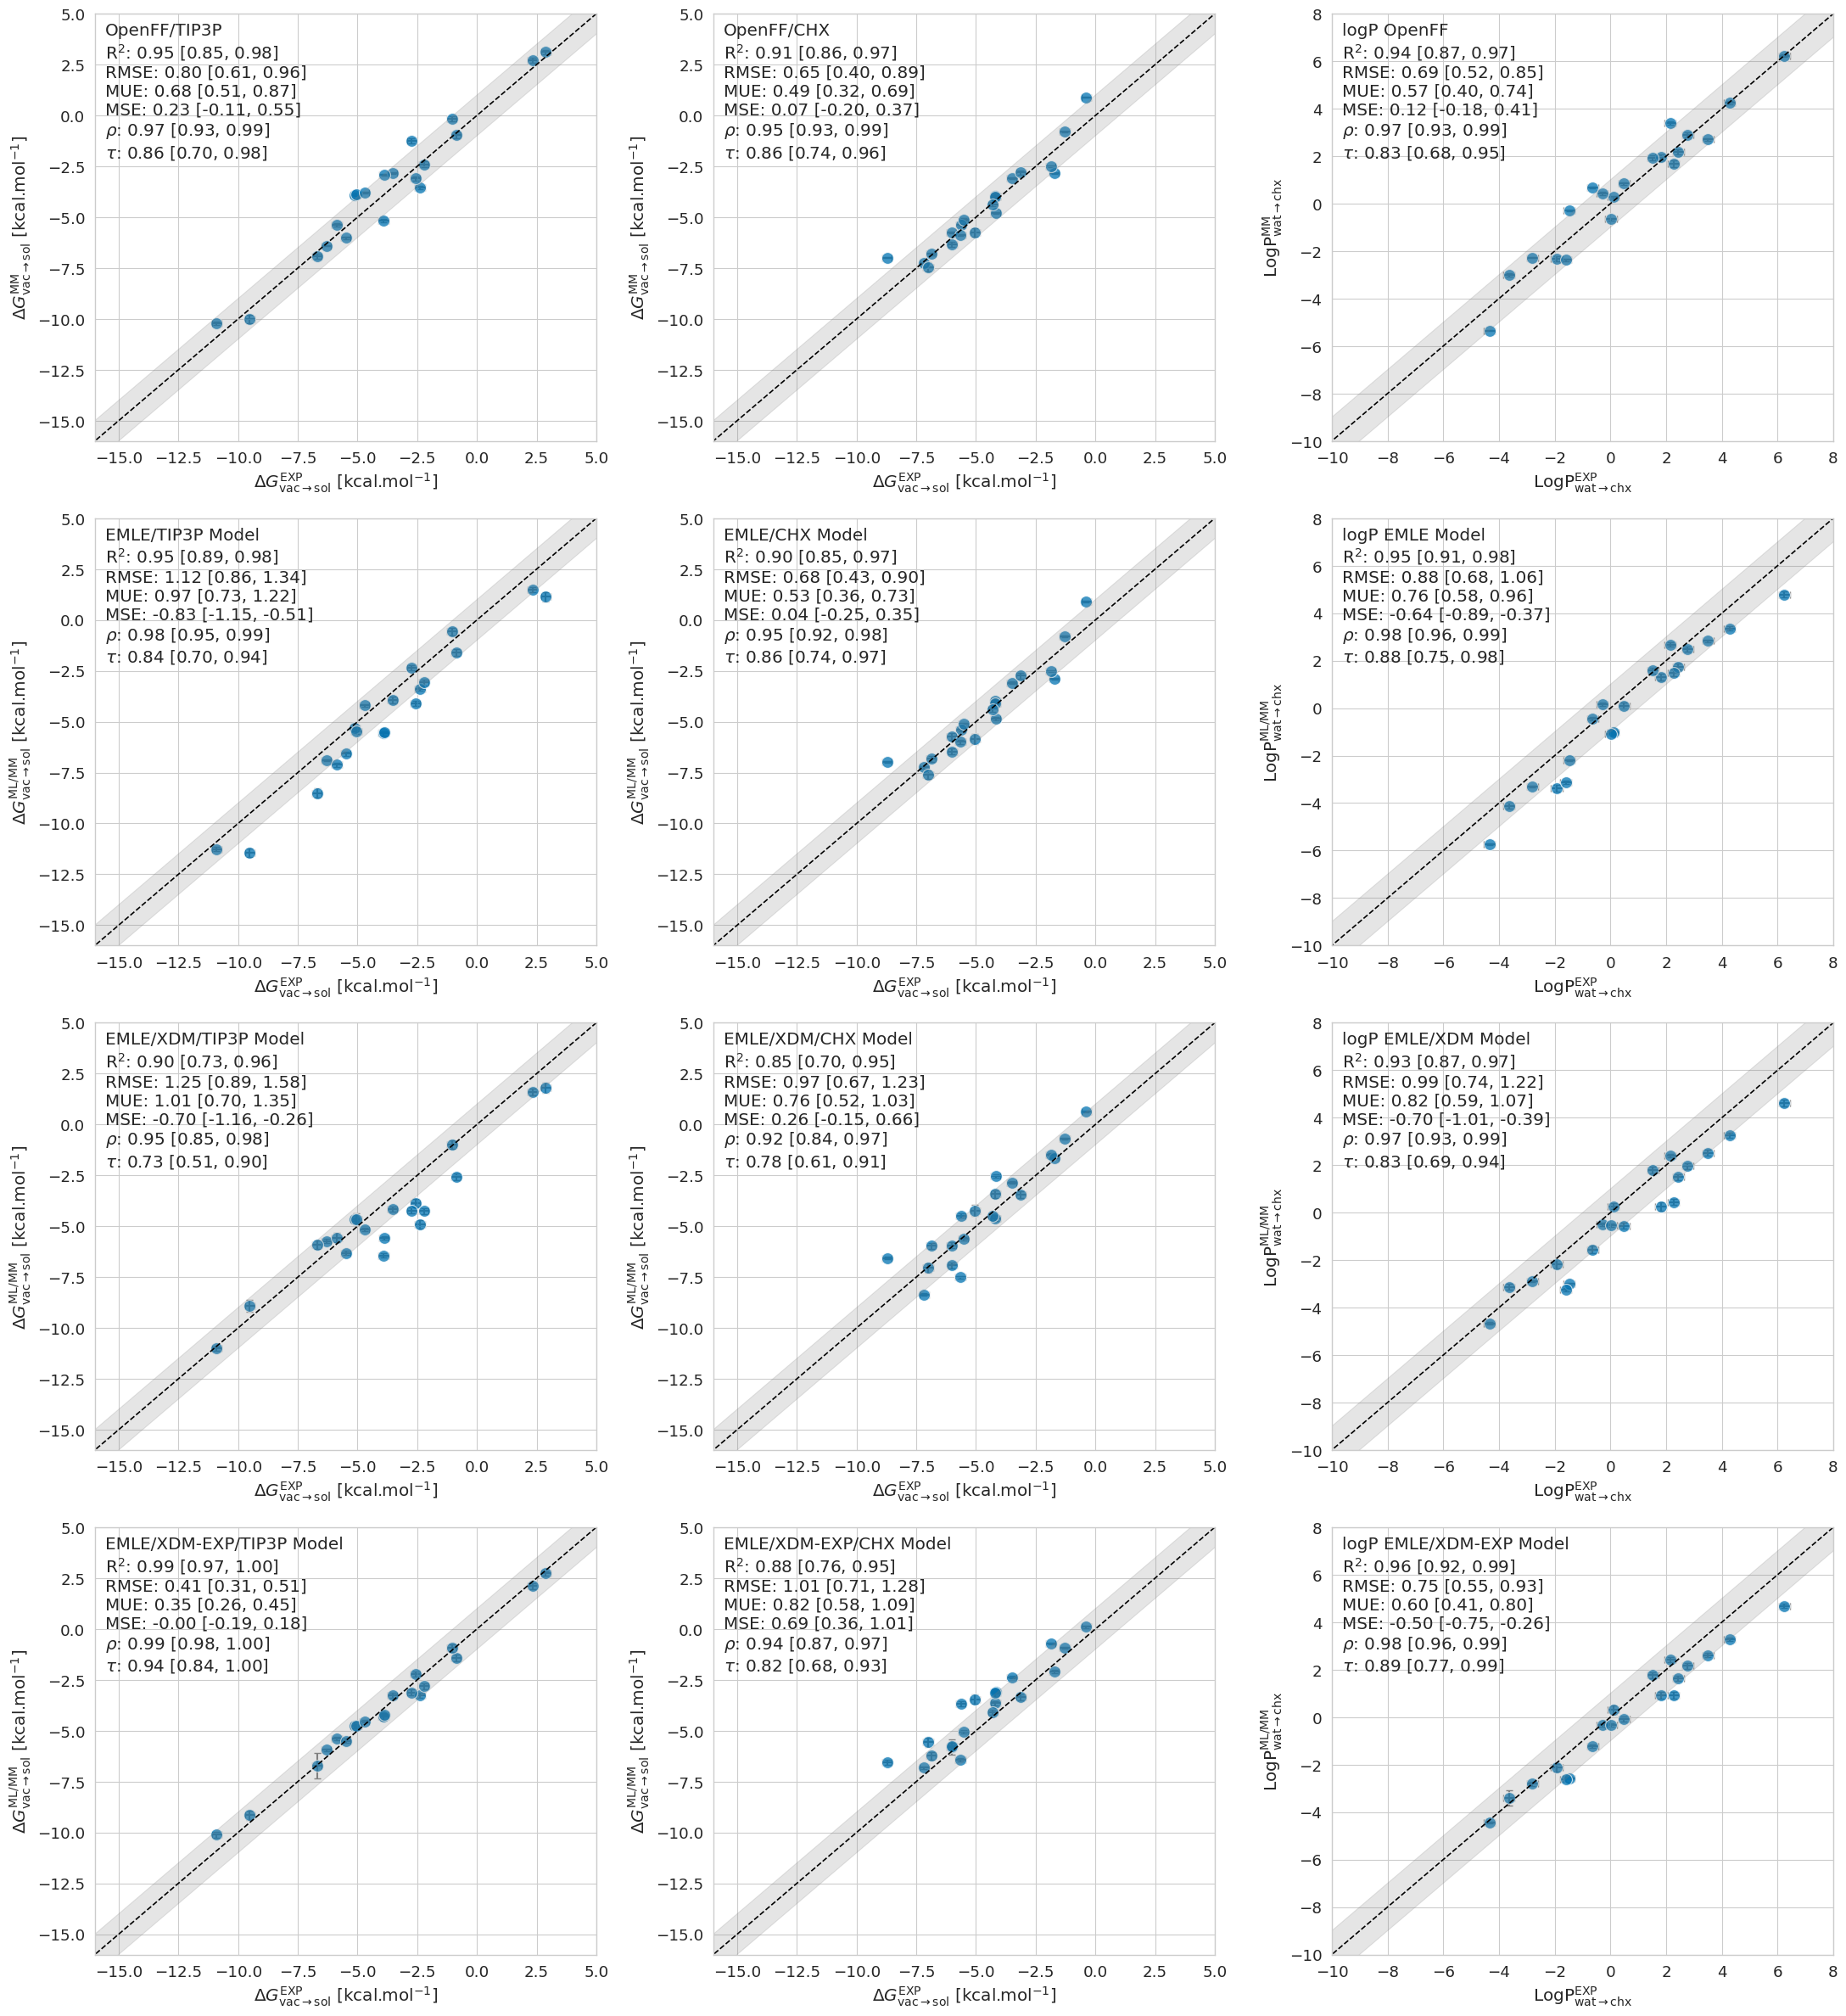

In [ ]:
sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)

columns_to_plot = df_data_mean.columns[3:]
num_plots = len(columns_to_plot)
ncols = 3
nrows = (num_plots + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(22, 6 * nrows), sharex=False, sharey=False
)

axes = axes.flatten()

xx = np.linspace(-100, 100, 100)
yy = xx

for i, column in enumerate(columns_to_plot):
    if column in ["EXP_WAT", "EXP_CHX", "logP EXP"]:
        continue

    if "logP" in column:
        x = df_data_mean["logP EXP"]
        y = df_data_mean[column]
    elif "TIP3P" in column:
        x = df_data_mean["EXP_WAT"]
        y = df_data_mean[column]
    elif "CHX" in column:
        x = df_data_mean["EXP_CHX"]
        y = df_data_mean[column]
    else:
        raise ValueError(f"Unknown column type: {column}")

    # Convert to numpy arrays
    x = x.to_numpy()
    y = y.to_numpy()

    # Drop nan at same indices in x and y
    valid_indices = ~(np.isnan(x) | np.isnan(y))
    x = x[valid_indices]
    y = y[valid_indices]

    if len(x) == 0 or len(y) == 0:
        continue

    metrics = ["R2", "RMSE", "MUE", "MSE", "rho", "KTAU"]
    statistics = {}
    statistics_string = ""
    statistic_type = "mle"
    statistic_name = {
        "RMSE": r"RMSE",
        "MUE": r"MUE",
        "MSE": r"MSE",
        "R2": r"R$^2$",
        "rho": r"$\rho$",
        "KTAU": r"$\tau$",
    }
    for statistic in metrics:
        statistics[statistic] = bootstrap_statistic(x, y, statistic=statistic)
        s = statistics[statistic]
        string = (
            f"{statistic_name[statistic]}: {s[statistic_type]:.2f} [{s['low']:.2f}, {s['high']:.2f}]"
            + "\n"
        )
        statistics_string += string

    sns.lineplot(ax=axes[i], x=xx, y=yy, color="black", linestyle="--")
    sns.scatterplot(ax=axes[i], x=x, y=y, alpha=0.75, s=100)

    axes[i].errorbar(
        x,
        y,
        xerr=df_data_error["EXP_WAT"]
        if "TIP3P" in column
        else df_data_error["EXP_CHX"],
        yerr=df_data_error[column]
        if "logP" not in column
        else df_data_error[column] * logP_const,
        fmt="none",  # no marker
        ecolor="gray",
        elinewidth=1.5,
        capsize=3,
        alpha=1.0,
        zorder=0,
    )

    if i in [0, 1]:
        axes[i].set_ylabel(
            r"$\Delta G^{\rm MM}_{\rm vac \rightarrow sol}$ [kcal.mol$^{-1}$]"
        )
    if i in [3, 4, 6, 7, 9, 10]:
        axes[i].set_ylabel(
            r"$\Delta G^{\rm ML/MM}_{\rm vac \rightarrow sol}$ [kcal.mol$^{-1}$]"
        )
    elif i in [2, 5, 8, 11]:
        axes[i].set_xlabel(
            r"$\mathrm{LogP}^{\mathrm{EXP}}_{\mathrm{wat} \rightarrow \mathrm{chx}}$"
        )

    if i in [0, 1, 3, 4, 6, 7, 9, 10]:
        axes[i].set_xlabel(
            r"$\Delta G^{\rm EXP}_{\rm vac \rightarrow sol}$ [kcal.mol$^{-1}$]"
        )

    if i in [5, 8, 11]:
        axes[i].set_ylabel(
            r"$\mathrm{LogP}^{\mathrm{ML/MM}}_{\mathrm{wat} \rightarrow \mathrm{chx}}$"
        )

    if i == 2:
        axes[i].set_ylabel(
            r"$\mathrm{LogP}^{\mathrm{MM}}_{\mathrm{wat} \rightarrow \mathrm{chx}}$"
        )

    small_dist = 1.0
    scale = np.linspace(-100, 100, 100)
    axes[i].fill_between(
        scale,
        scale - small_dist,
        scale + small_dist,
        color="grey",
        alpha=0.2,
    )
    """
    axes[i].set_title(
        f"{column}\n{statistics_string}",
        loc="right",
        horizontalalignment="right",
        pad=1,
    )
    """

    axes[i].text(
        0.02,
        0.98,
        f"{column}\n{statistics_string}",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
    )

    axes[i].grid(True)
    xmin = ymin = -16
    xmax = ymax = 5
    axes[i].set_xlim(xmin, xmax)
    axes[i].set_ylim(ymin, ymax)

    if "logP" in column:
        axes[i].set_xlim(-10, 8)
        axes[i].set_ylim(-10, 8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
"""
labels = ["A", "B", "C", "D", "E", "F", "G", "H"]
for ax, label in zip(axes, labels):
    ax.set_aspect("equal", "box")
    ax.text(
        -0.10,
        1.0,
        label,
        transform=ax.transAxes,
        fontsize=32,
        fontweight="bold",
        va="top",
        ha="right",
    )
"""

plt.tight_layout()
# plt.subplots_adjust(hspace=0.025
plt.savefig("overall_benchmark.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

In [9]:
df_data_mean = pd.DataFrame(
    {
        "logP EXP": logP_EXP_MEAN,
        "OpenFF/TIP3P": logP_MM_MEAN,
        "EMLE Model": logP_PATCHED_MEAN,
        r"EMLE/XDM Model": logP_PATCHED_XDM_MEAN,
        r"EMLE/XDM-EXP Model": logP_PATCHED_XDM_EXP_MEAN,
    }
)

df_data_std = pd.DataFrame(
    {
        "logP EXP": EXP_CHX_STD,
        "OpenFF/TIP3P": logP_MM_STD,
        "EMLE Model": dG_PATCHED_STD_CHX * logP_const,
        r"EMLE/XDM Model": dG_PATCHED_XDM_STD_CHX,
        r"EMLE/XDM-EXP Model": dG_PATCHED_XDM_EXP_STD_CHX,
    }
)

df_data_error = pd.DataFrame(
    {
        "logP EXP": EXP_CHX_STD,
        "OpenFF/TIP3P": logP_MM_ERROR,
        "EMLE Model": logP_PATCHED_ERROR,
        r"EMLE/XDM Model": logP_PATCHED_XDM_ERROR,
        r"EMLE/XDM-EXP Model": logP_PATCHED_XDM_EXP_ERROR,
    }
)

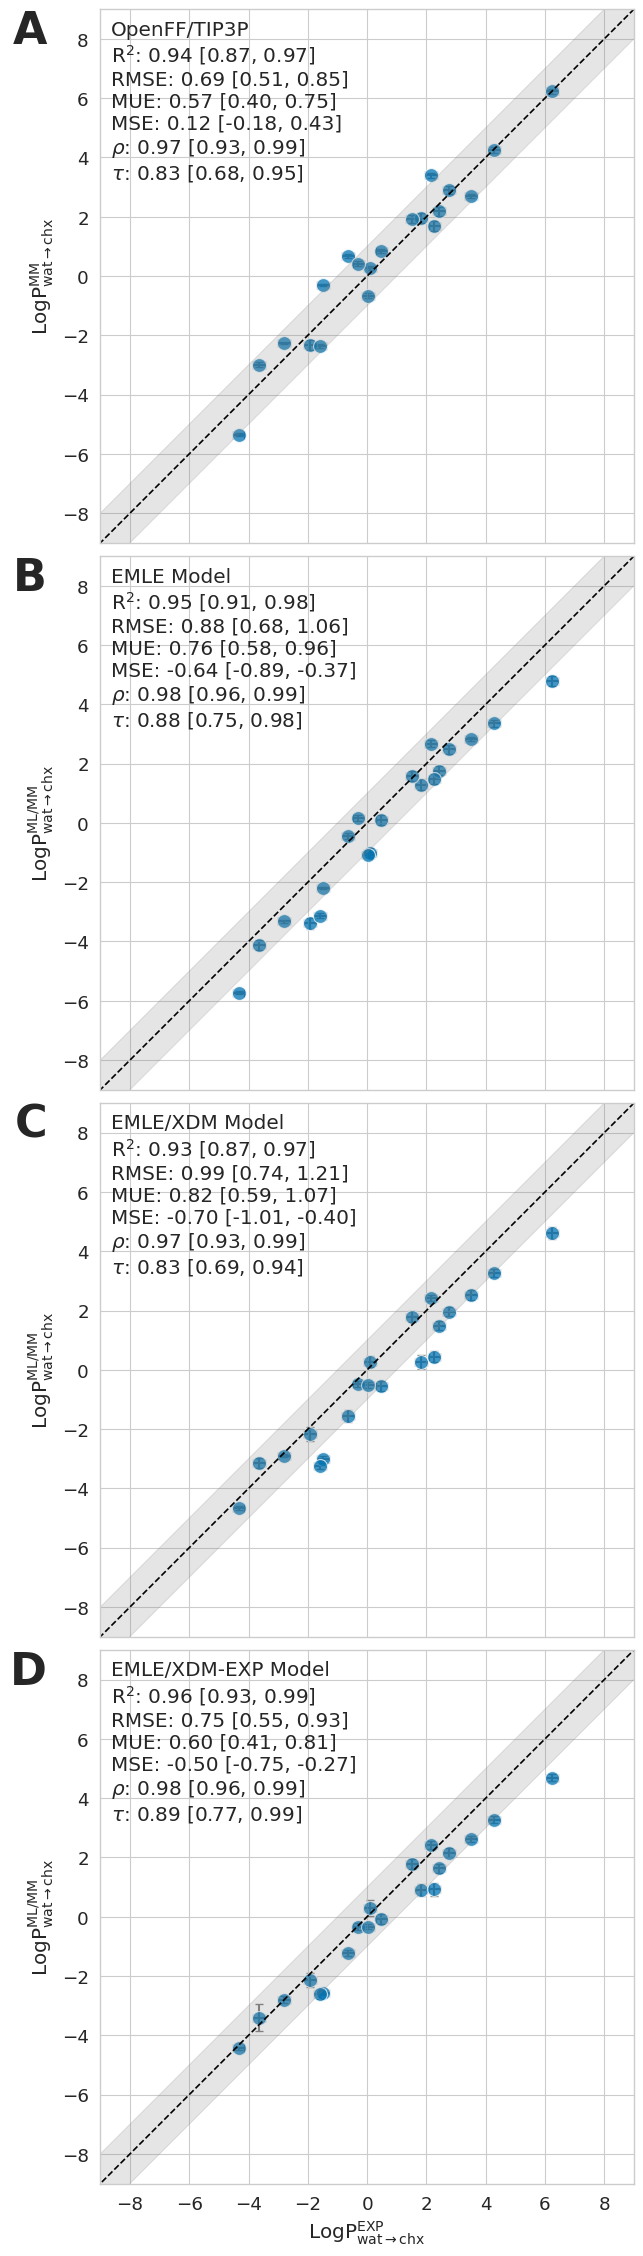

In [ ]:
sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)

columns_to_plot = df_data_mean.columns[1:]
num_plots = len(columns_to_plot)
ncols = 1
nrows = (num_plots + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(8, 6 * nrows - 1.2), sharex=False, sharey=False
)

axes = axes.flatten()

xx = np.linspace(-100, 100, 100)
yy = xx

for i, column in enumerate(columns_to_plot):
    x = df_data_mean["logP EXP"]
    y = df_data_mean[column]

    metrics = ["R2", "RMSE", "MUE", "MSE", "rho", "KTAU"]
    statistics = {}
    statistics_string = ""
    statistic_type = "mle"
    statistic_name = {
        "RMSE": r"RMSE",
        "MUE": r"MUE",
        "MSE": r"MSE",
        "R2": r"R$^2$",
        "rho": r"$\rho$",
        "KTAU": r"$\tau$",
    }
    for statistic in metrics:
        statistics[statistic] = bootstrap_statistic(x, y, statistic=statistic)
        s = statistics[statistic]
        string = (
            f"{statistic_name[statistic]}: {s[statistic_type]:.2f} [{s['low']:.2f}, {s['high']:.2f}]"
            + "\n"
        )
        statistics_string += string

    sns.lineplot(ax=axes[i], x=xx, y=yy, color="black", linestyle="--")
    sns.scatterplot(ax=axes[i], x=x, y=y, alpha=0.75, s=100)

    axes[i].errorbar(
        x,
        y,
        xerr=df_data_error["logP EXP"],
        yerr=df_data_error[column],
        fmt="none",  # no marker
        ecolor="gray",
        elinewidth=1.5,
        capsize=3,
        alpha=1.0,
        zorder=0,
    )
    if i == 0:
        axes[i].set_ylabel(
            r"$\mathrm{LogP}^{\mathrm{MM}}_{\mathrm{wat} \rightarrow \mathrm{chx}}$"
        )
    else:
        axes[i].set_ylabel(
            r"$\mathrm{LogP}^{\mathrm{ML/MM}}_{\mathrm{wat} \rightarrow \mathrm{chx}}$"
        )

    if i == 3:
        axes[i].set_xlabel(
            r"$\mathrm{LogP}^{\mathrm{EXP}}_{\mathrm{wat} \rightarrow \mathrm{chx}}$"
        )

    if i != len(axes) - 1:
        axes[i].set_xticklabels([])
        axes[i].set_xlabel("")

    small_dist = 1.0
    scale = np.linspace(-100, 100, 100)
    axes[i].fill_between(
        scale,
        scale - small_dist,
        scale + small_dist,
        color="grey",
        alpha=0.2,
    )
    """
    axes[i].set_title(
        f"{column}\n{statistics_string}",
        loc="right",
        horizontalalignment="right",
        pad=1,
    )
    """

    axes[i].text(
        0.02,
        0.98,
        f"{column}\n{statistics_string}",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
    )

    axes[i].grid(True)
    xmin = ymin = -9
    xmax = ymax = 9
    axes[i].set_xlim(xmin, xmax)
    axes[i].set_ylim(ymin, ymax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

labels = ["A", "B", "C", "D"]
for ax, label in zip(axes, labels):
    ax.set_aspect("equal", "box")
    ax.text(
        -0.10,
        1.0,
        label,
        transform=ax.transAxes,
        fontsize=32,
        fontweight="bold",
        va="top",
        ha="right",
    )

plt.tight_layout()
plt.subplots_adjust(hspace=0.025)
plt.savefig("logP_benchmark.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()

# Statistical Analysis

In [11]:
dG_PATCHED_XDM_MEAN_WAT.to_numpy() - np.array(EXP_WAT_MEAN)


array([-0.73538796, -1.07310705, -1.70591612, -2.52038339,  0.5829278 ,
        0.44712682,  0.30767267,  0.78679959,  0.39419216, -1.29419248,
       -2.53623066, -0.64091642, -2.03281472,  0.59176297, -1.68522593,
       -0.46383744, -0.82791428, -0.10308214,  0.04187633, -1.49329354])

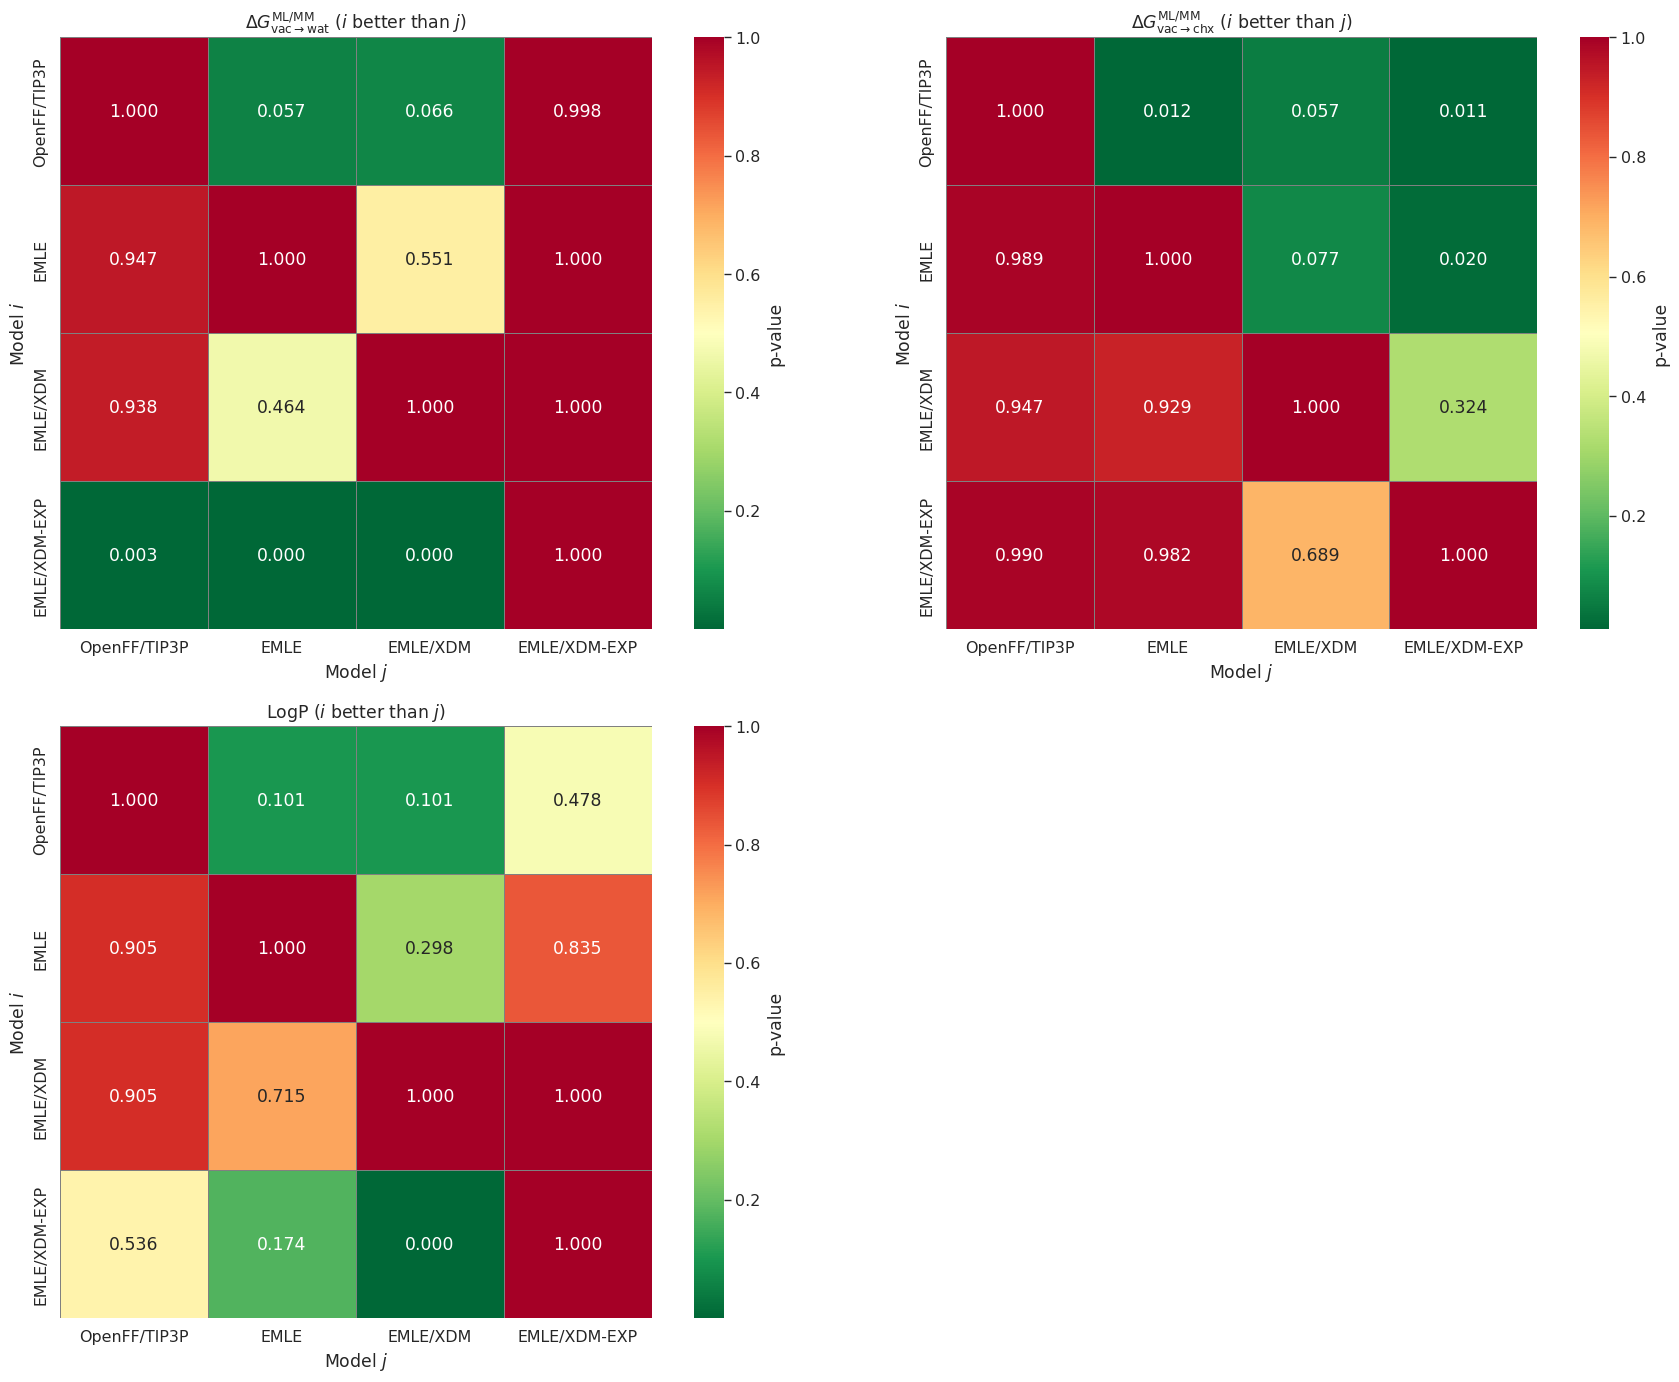

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import wilcoxon

abs_error_MM_WAT = np.abs(dG_MM_MEAN_WAT.to_numpy() - np.array(EXP_WAT_MEAN))
abs_error_PATCHED_WAT = np.abs(dG_PATCHED_MEAN_WAT.to_numpy() - np.array(EXP_WAT_MEAN))
abs_error_PATCHED_XDM_WAT = np.abs(
    dG_PATCHED_XDM_MEAN_WAT.to_numpy() - np.array(EXP_WAT_MEAN)
)
abs_error_PATCHED_XDM_EXP_WAT = np.abs(
    dG_PATCHED_XDM_EXP_MEAN_WAT.to_numpy() - np.array(EXP_WAT_MEAN)
)

abs_error_MM_CHX = np.abs(dG_MM_MEAN_CHX.to_numpy() - np.array(EXP_CHX_MEAN))
abs_error_PATCHED_CHX = np.abs(dG_PATCHED_MEAN_CHX.to_numpy() - np.array(EXP_CHX_MEAN))
abs_error_PATCHED_XDM_CHX = np.abs(
    dG_PATCHED_XDM_MEAN_CHX.to_numpy() - np.array(EXP_CHX_MEAN)
)
abs_error_PATCHED_XDM_EXP_CHX = np.abs(
    dG_PATCHED_XDM_EXP_MEAN_CHX.to_numpy() - np.array(EXP_CHX_MEAN)
)

abs_error_logP_MM = np.abs(logP_MM_MEAN.to_numpy() - np.array(logP_EXP_MEAN))
abs_error_logP_PATCHED = np.abs(logP_PATCHED_MEAN.to_numpy() - np.array(logP_EXP_MEAN))
abs_error_logP_PATCHED_XDM = np.abs(
    logP_PATCHED_XDM_MEAN.to_numpy() - np.array(logP_EXP_MEAN)
)
abs_error_logP_PATCHED_XDM_EXP = np.abs(
    logP_PATCHED_XDM_EXP_MEAN.to_numpy() - np.array(logP_EXP_MEAN)
)


names = ["OpenFF/TIP3P", "EMLE", "EMLE/XDM", "EMLE/XDM-EXP"]


def compute_wilcoxon_matrix(errors):
    n = len(errors)
    p_values = np.ones((n, n))

    for i in range(n):
        for j in range(n):
            if i != j:
                try:
                    _, p = wilcoxon(errors[i], errors[j], alternative="less")
                    p_values[i, j] = p
                except ValueError:
                    p_values[i, j] = np.nan

    return p_values


sns.set(style="whitegrid", context="paper", font_scale=1.3)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))


datasets = [
    (
        [
            abs_error_MM_WAT,
            abs_error_PATCHED_WAT,
            abs_error_PATCHED_XDM_WAT,
            abs_error_PATCHED_XDM_EXP_WAT,
        ],
        r"$\Delta G^{\mathrm{ML/MM}}_{\mathrm{vac} \rightarrow \mathrm{wat}}$ ($i$ better than $j$)",
    ),
    (
        [
            abs_error_MM_CHX,
            abs_error_PATCHED_CHX,
            abs_error_PATCHED_XDM_CHX,
            abs_error_PATCHED_XDM_EXP_CHX,
        ],
        r"$\Delta G^{\mathrm{ML/MM}}_{\mathrm{vac} \rightarrow \mathrm{chx}}$ ($i$ better than $j$)",
    ),
    (
        [
            abs_error_logP_MM,
            abs_error_logP_PATCHED,
            abs_error_logP_PATCHED_XDM,
            abs_error_logP_PATCHED_XDM_EXP,
        ],
        r"LogP ($i$ better than $j$)",
    ),
]


# -----------------------------
# Plot loop
# -----------------------------
for ax, (errors, title) in zip(axes.flatten(), datasets):
    p_values = compute_wilcoxon_matrix(errors)

    sns.heatmap(
        p_values,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r",
        xticklabels=names,
        yticklabels=names,
        cbar_kws={"label": "p-value"},
        linewidths=0.5,
        linecolor="gray",
        square=True,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("Model $j$")
    ax.set_ylabel("Model $i$")


# Delete any unused subplots
for j in range(len(datasets), len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.savefig("wilcoxon_transfer_free_energies.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
for i, arr in enumerate(
    [
        abs_error_MM_CHX,
        abs_error_PATCHED_CHX,
        abs_error_PATCHED_XDM_CHX,
        abs_error_PATCHED_XDM_EXP_CHX,
    ]
):
    print(i, np.mean(arr), np.std(arr), len(arr))

0 0.49426306434212125 0.4249112022705262 20
1 0.5250848908730277 0.42829828400917436 20
2 0.764352407210583 0.5914713220262968 20
3 0.822420140392879 0.583926513175199 20
